# 03 - Analyse Apriori des Combinaisons de Competences

Ce notebook utilise l'algorithme Apriori pour identifier les associations frequentes entre competences.

Objectifs:
- extraire les itemsets frequents
- generer des regles d'association
- interpreter les regles les plus utiles pour les recommandations skills

In [1]:
import pandas as pd  
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import joblib

## Etape 1 - Chargement du dataset encode

On charge le dataset issu du notebook Random Forest et on verifie sa structure.

In [2]:
df = pd.read_csv('dataset_encode.csv')
print(df.shape)

(10197, 63)


## Etape 2 - Selection des colonnes skills

On retire les colonnes de contexte (poste, entreprise, salaire, etc.) pour garder uniquement les variables de competences.

In [3]:
print(df.columns.tolist())

['job_title', 'company', 'location', 'post_date', 'seniority_level', 'skills', 'salary', 'skills_clean', 'python', 'java', 'aws', 'javascript', 'sql', 'agile', 'git', 'c#', 'software engineering', 'kubernetes', 'c++', 'docker', 'react', 'typescript', 'software development', 'linux', 'azure', 'angular', 'go', 'machine learning', 'html', 'css', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'gcp', 'computer science', 'c', 'agile development', 'postgresql', 'nosql', 'mysql', 'confluence', 'scala', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', 'terraform', 'kafka', 'data structures', 'seniority_encoded', 'job_category_data engineer', 'job_category_data scientist', 'job_category_ml engineer', 'job_category_software engineer']


In [4]:
# Colonnes a exclure
non_skills = ['job_title', 'company', 'location', 'post_date', 
              'seniority_level', 'skills', 'salary', 'seniority_encoded',
              'job_category_data engineer', 'job_category_data scientist', 
              'job_category_ml engineer', 'job_category_software engineer','skills_clean']

# Garder seulement les skills
df_skills = df.drop(columns=non_skills)
print(df_skills.shape)
print(df_skills.head())

(10197, 50)
   python  java  aws  javascript  sql  agile  git  c#  software engineering  \
0       1     0    0           0    0      0    0   0                     0   
1       1     0    0           0    1      0    0   0                     0   
2       1     0    0           0    1      0    1   0                     0   
3       0     0    0           0    0      0    0   0                     0   
4       0     0    0           0    0      0    0   0                     0   

   kubernetes  ...  confluence  scala  distributed systems  sql server  \
0           0  ...           0      1                    0           0   
1           0  ...           0      0                    0           0   
2           1  ...           0      0                    0           0   
3           0  ...           0      0                    0           0   
4           0  ...           0      0                    0           0   

   continuous integration  software design  rest  terraform  kafka  

In [5]:
df_skills = df_skills.astype(bool)
print(df_skills.dtypes.value_counts())

bool    50
Name: count, dtype: int64


## Etape 3 - Extraction des itemsets frequents (Apriori)

On transforme les colonnes skills en booleen puis on applique Apriori avec un support minimum de 5%.

In [6]:
frequent_items = apriori(df_skills, min_support=0.05, use_colnames=True)
print(frequent_items.shape)
print(frequent_items.head(10))

(138, 2)
    support                itemsets
0  0.382367                (python)
1  0.314700                  (java)
2  0.263313                   (aws)
3  0.261548            (javascript)
4  0.248308                   (sql)
5  0.199863                 (agile)
6  0.178974                   (git)
7  0.174561                    (c#)
8  0.171717  (software engineering)
9  0.160734            (kubernetes)


## Etape 4 - Generation des regles d'association

A partir des itemsets frequents, on genere des regles avec une confiance minimale de 50%.

In [7]:
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)
print(rules.shape)
print(rules[['antecedents', 'consequents', 'confidence']].head(10))

(122, 14)
          antecedents consequents  confidence
0              (java)    (python)    0.566532
1               (aws)    (python)    0.587337
2               (sql)    (python)    0.573855
3        (kubernetes)    (python)    0.553996
4               (c++)    (python)    0.542495
5            (docker)    (python)    0.544005
6             (linux)    (python)    0.543060
7                (go)    (python)    0.844779
8  (machine learning)    (python)    0.639810
9               (aws)      (java)    0.533333


## Etape 5 - Visualisation des meilleures combinaisons

Le graphique suivant affiche les 10 regles ayant le plus fort lift (association la plus forte).

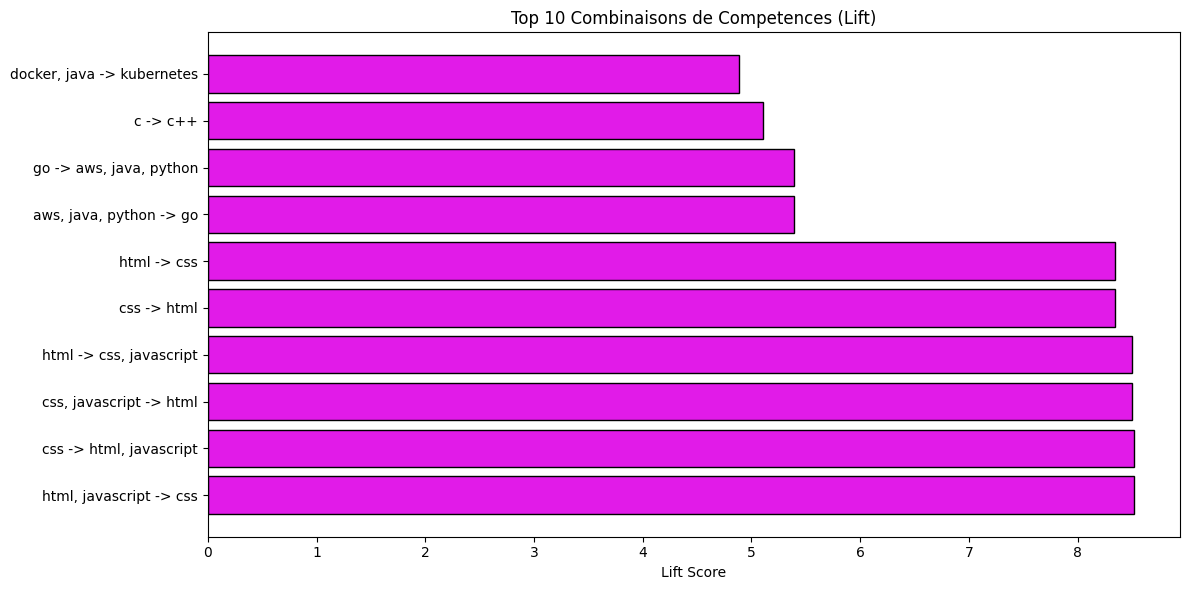

In [8]:
top_rules = rules.nlargest(10, 'lift')

plt.figure(figsize=(12, 6))
labels = [
    f"{', '.join(sorted(list(r['antecedents'])))} -> {', '.join(sorted(list(r['consequents'])))}"
    for _, r in top_rules.iterrows()
]
plt.barh(labels, top_rules['lift'], color="#e11be8", edgecolor='black')
plt.title('Top 10 Combinaisons de Competences (Lift)')
plt.xlabel('Lift Score')
plt.tight_layout()
plt.show()

## Interpretation et conclusion

Ce notebook met en evidence des combinaisons de competences qui apparaissent souvent ensemble.

Points cles:
- un support eleve indique une combinaison frequente dans le marche
- une confiance elevee suggere une bonne capacite de recommandation
- un lift > 1 signale une association utile (non due au hasard)

Utilisation pratique:
- enrichir le systeme de recommandation avec des skills complementaires
- proposer des parcours d'apprentissage par blocs de competences
- prioriser les combinaisons les plus demandees pour augmenter l'employabilite

In [9]:
# Supprimer skills_clean des colonnes
joblib.dump(rules, 'apriori_rules.pkl')

['apriori_rules.pkl']

In [10]:
X = df.drop(columns=['skills', 'job_title', 'seniority_level', 
                      'company', 'location', 'post_date', 'salary','skills_clean'])
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print('✅ Colonnes sauvegardées !')

✅ Colonnes sauvegardées !


In [ ]:
print(rules['consequents'].head(10))
print(df.columns.tolist())

0    (python)
1    (python)
2    (python)
3    (python)
4    (python)
5    (python)
6    (python)
7    (python)
8    (python)
9      (java)
Name: consequents, dtype: object
['job_title', 'company', 'location', 'post_date', 'seniority_level', 'skills', 'salary', 'skills_clean', 'python', 'java', 'aws', 'javascript', 'sql', 'agile', 'git', 'c#', 'software engineering', 'kubernetes', 'c++', 'docker', 'react', 'typescript', 'software development', 'linux', 'azure', 'angular', 'go', 'machine learning', 'html', 'css', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'gcp', 'computer science', 'c', 'agile development', 'postgresql', 'nosql', 'mysql', 'confluence', 'scala', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', 'terraform', 'kafka', 'data structures', 'seniority_encoded', 'job_category_data engineer', 'job_category_data scientist', 'job_category_ml engineer'

: 